# Contexto

FinanceGuard es un banco digital que ha experimentado un crecimiento exponencial en los últimos años, alcanzando 10000 clientes activos. Sin embargo, la dirección ha detectado un incremento preocupante en la tasa de abandono de clientes (churn), que actualmente alcanza el 20% anual, resultando en pérdidas millonarias.


## Qué es un churn bancario?

Es la pérdida de clientes de una entidad financiera, es decir, cuando un cliente deja de usar los productos o servicios de un banco y se pasa a otro o abandona el sistema.

La variable objetivo es Exited:

    * Exited = 1 → abandonó (churn)
    * Exited = 0 → sigue activo

# Objetivo

Desarrollar un modelo de Machine Learning completo que prediga qué clientes tienen mayor probabilidad de abandonar el banco. Este modelo permitirá al equipo de retención implementar estrategias personalizadas para retener a los clientes en riesgo, con el objetivo de reducir el churn al 15%.


## Exploración inicial del dataset

### Descripción de columnas

* RowNumber: Índice de la fila.
* CustomerId: Identificador único para cada cliente.
* Surname: Apellido del cliente (puede no ser útil para el análisis).
* CreditScore: Puntuación crediticia del cliente [300 : 850].
* Geography: País del cliente (ej. Francia, España).
* Gender: Género del cliente (ej. Masculino, Femenino).
* Age: Edad del cliente.
* Tenure: Número de años que el cliente ha estado con el banco.
* Balance: Saldo de cuenta del cliente.
* NumOfProducts: Número de productos que ha comprado el cliente.
* HasCrCard: Si el cliente tiene tarjeta de crédito (1 = Sí, 0 = No).
* IsActiveMember: Si el cliente es un miembro activo (1 = Sí, 0 = No).
* EstimatedSalary: Salario anual estimado del cliente.
* Exited: Si el cliente dejó el banco (1 = Sí, 0 = No) – esta es la variable objetivo.


## 0. Vista previa de los datos

In [47]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)



In [23]:
# Carga de dataset
CSV_PATH = "Churn_Modelling.csv"
df = pd.read_csv(CSV_PATH)

# Visualizacion de del dataset
print("=== HEAD ===")
print(df.head())

=== HEAD ===
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  


In [24]:
#Informacion del dataset
print("=== INFO ===")
print(df.info())

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [25]:
#Forma del dataset
print("=== Shape ===")
print(df.shape)

=== Shape ===
(10000, 14)


El dataset tiene:
- Cantidad de columnas: 14
- Cantidad de filas: 10000

Los tipos de datos que tienen las variables son correctas por el momento aunque se decide eliminar las columnas innecesarias para la prediccion como 'RowNumber', 'CustomerId' y 'Surname'.

In [26]:
# eliminamos las columnas innecesarias
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [27]:
#Descripcion variables numericas
print("=== Descripcion variables numericas ===")
print(df.describe())


=== Descripcion variables numericas ===
        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        

Las variables numericas tienen valores aceptables

#### Algunos puntos a resaltar:

* La edad promedio de los clientes es de 39 años y la edad maxima de el/los cliente/s es de 92 años.
* Existen clientes que tienen menos de un año de antiguedad.
* El salario estimado anual del 50% tiene es de al menos 100.000 USD


## 1. Limpieza de datos

In [28]:
#Porcentaje de valores nulos (missing values)
print(df.isnull().mean()*100)

CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64


No se encontraron valores nulos

In [29]:
#visualizo valores unicos geograficos y de genero
valores_geo = df['Geography'].unique()
valores_gen = df['Gender'].unique()

print(f"valores unicos geograficos:", valores_geo)
print(f"valores unicos genero:", valores_gen)

valores unicos geograficos: ['France' 'Spain' 'Germany']
valores unicos genero: ['Female' 'Male']


Los valores de la variables categoricas son correctos

In [30]:
# Validacion de datos duplicados
df.duplicated().sum()

np.int64(0)

No se encontraron datos duplicados

### Outliers

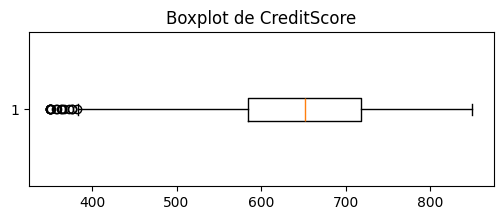

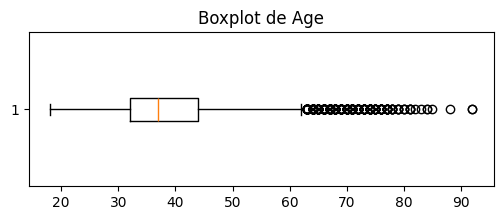

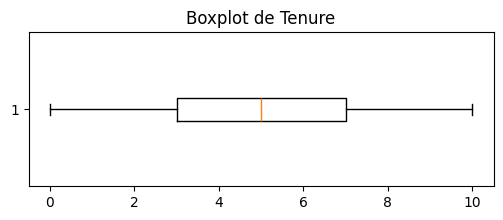

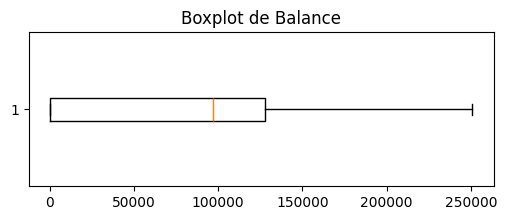

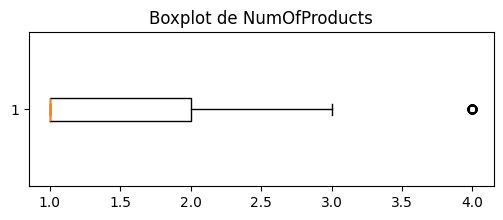

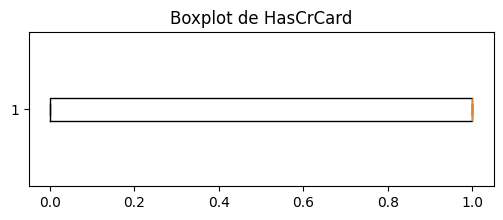

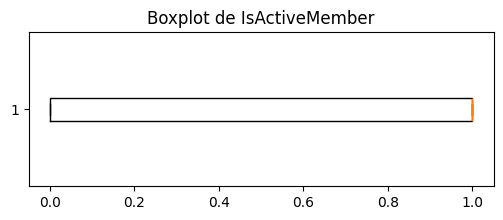

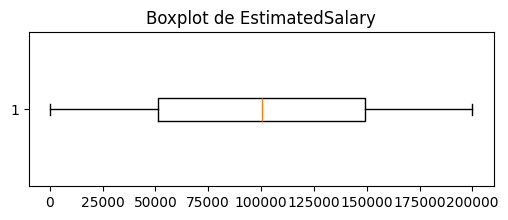

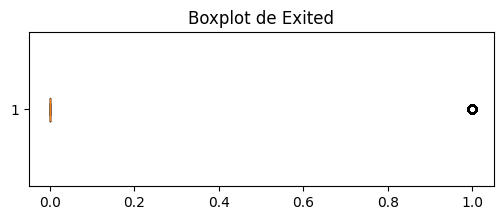

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [31]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for i in range(len(num_cols)):
    plt.figure(figsize=(6,2))
    plt.boxplot(df[num_cols[i]], vert=False)
    plt.title(f"Boxplot de {num_cols[i]}")
    plt.show()
    
print(num_cols)

Se visualizan outliers en 'Age', 'CreditScore', 'NumOfProducts'. Posteriormente se decide si se realiza un tratamiento con estos o se decide dejarlos.


## 2. Análisis Exploratorio de Datos (EDA)

In [32]:
# Variables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n=== Columnas numéricas ===")
print(num_cols)

print("\n=== Columnas categóricas ===")
print(cat_cols)


=== Columnas numéricas ===
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

=== Columnas categóricas ===
['Geography', 'Gender']


### 2.1 Análisis Univariado : Distribución de la variable objetivo

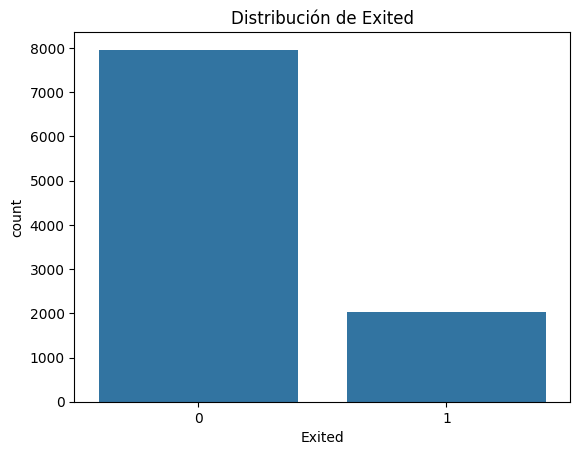

In [33]:
sns.countplot(data=df, x="Exited")
plt.title("Distribución de Exited")
plt.show()

In [34]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Se visualiza un desbalance del target de un 79,63% = 0 y un 20,37% = 1

### 2.2 Análisis Bivariado : Variables numéricas vs Churn

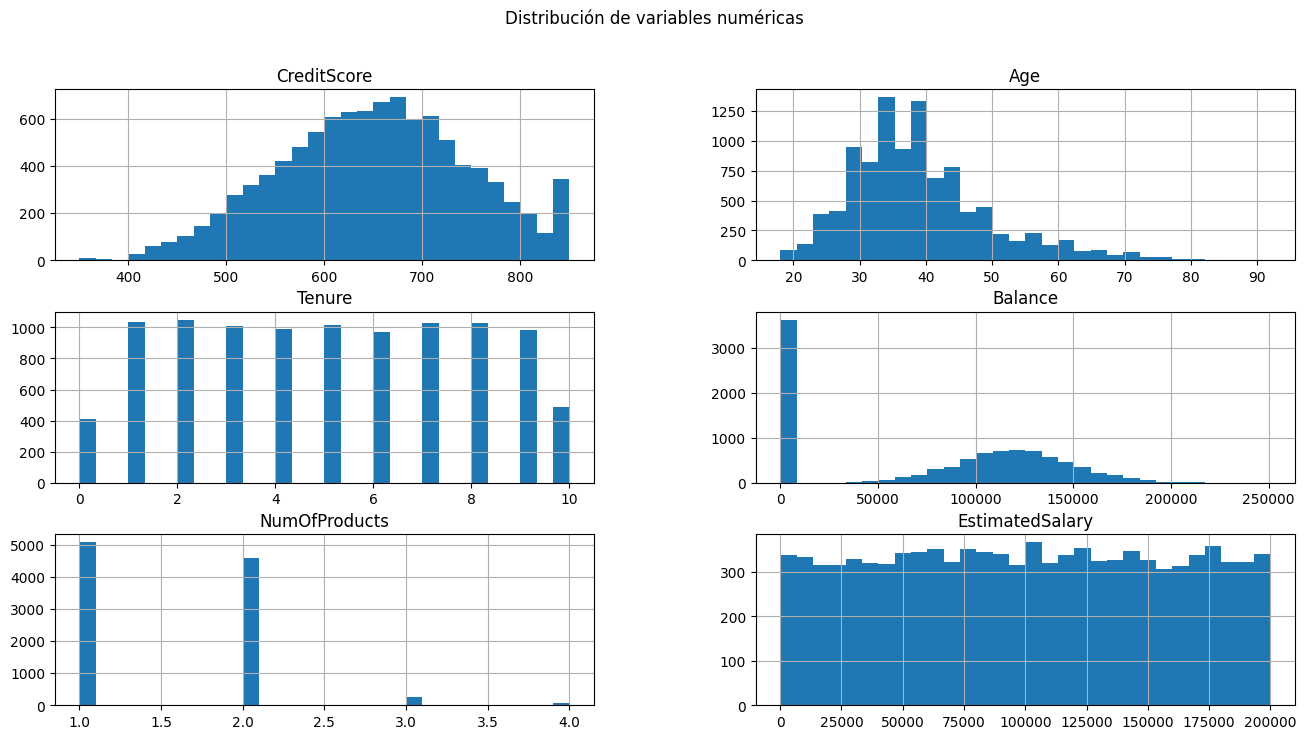

In [35]:
# Variables numéricas típicas
num_cols = ["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"]
df[num_cols].hist(bins=30, figsize=(16,8))
plt.suptitle("Distribución de variables numéricas")
plt.show()

Se toma la decision de trabajar con los outliers en 'Age', 'CreditScore', 'NumOfProducts'

Se puede visualizar en este dataset:

**CreditScore**
- Distribución aproximadamente normal
- Pico alrededor de 600–700
- Pocos valores extremos (<400 o >800)

**Age**
- Distribución asimétrica a la derecha
- Mayor concentración entre 30 y 45 años
- Cola larga hasta edades altas (60–90)

**Tenure (antiguedad)**
- Distribución discreta y casi uniforme
- Valores entre 0 y 10 años

**Balance**
- Gran cantidad de clientes con balance = 0
- Para el resto, distribución casi normal centrada ~100.000

**NumOfProducts**
- Distribución altamente discreta
- Mayoría con 1 o 2 productos
- Muy pocos con 3 o 4

**EstimatedSalary**
- Distribución casi uniforme
- No hay picos claros
- Valores repartidos de manera homogénea

### 2.3 Análisis Bivariado : Variables categóricas vs Churn

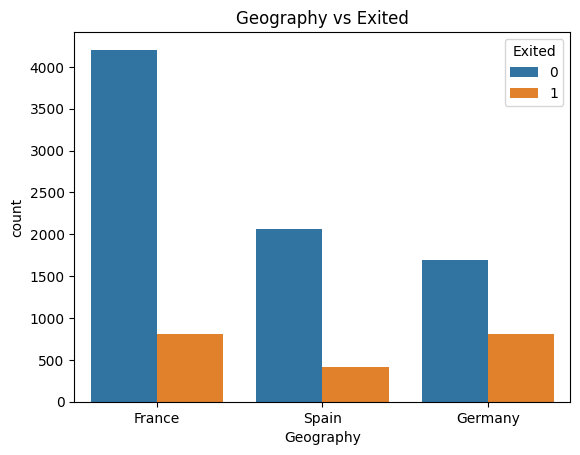

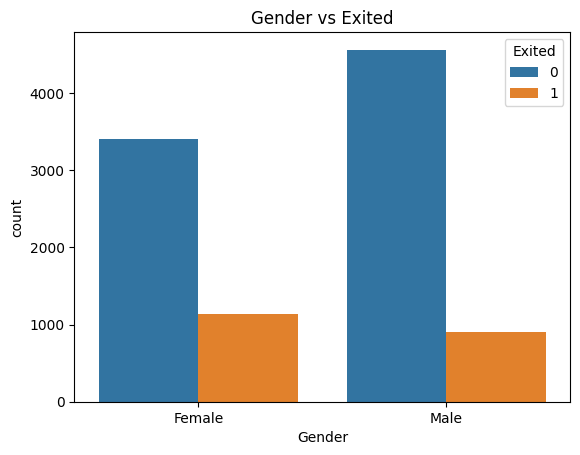

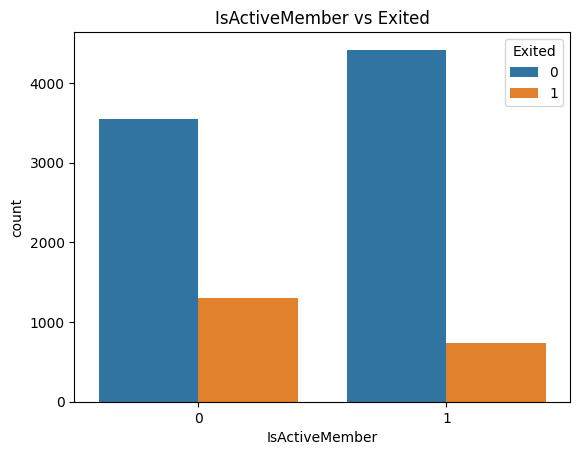

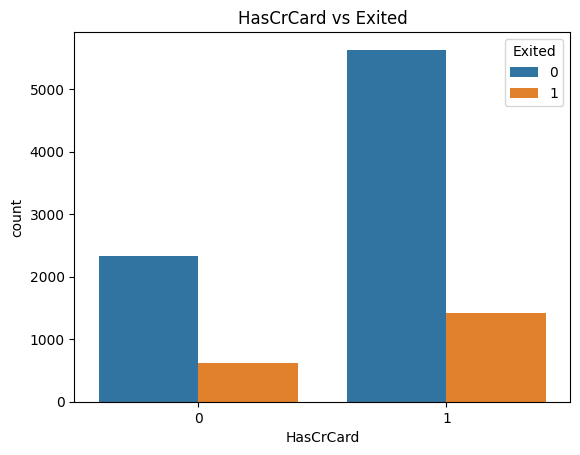

In [36]:
# Categóricas
for c in ["Geography","Gender", "IsActiveMember", "HasCrCard"]:
    sns.countplot(data=df, x=c, hue="Exited")
    plt.title(f"{c} vs Exited")
    plt.xticks(rotation=0)
    plt.show()

**Geography vs Exited**
- *Alemania* presenta una proporción de churn claramente mayor.
- *Francia* tiene muchos clientes pero churn relativamente bajo.
- *España* muestra el churn más bajo.

**Gender vs Exited**
- Hay más clientes hombres que mujeres.
- Sin embargo, las mujeres presentan una proporción mayor de churn.

**IsActiveMember vs Exited**
- Los clientes no activos (IsActiveMember = 0) presentan mucho más churn.
- Los clientes activos (IsActiveMember = 1) abandonan mucho menos

**HasCrCard vs Exited**
- La mayoría de los clientes tienen tarjeta (HasCrCard = 1).
- Tanto en clientes con tarjeta como sin tarjeta hay chur



## 3. Preprocesamiento de Datos

### 3.1 Feature Engineering (básico)

In [37]:
X = df.drop(columns=['Exited']).copy() #features
y = df["Exited"].copy()  # exited (target)

### 3.2 Split Train/Test

¿Por qué dividir ANTES del preprocesamiento?
- Previene data leakage (filtración de información)
- El preprocesamiento se ajusta solo con datos de entrenamiento
- Simulamos condiciones reales donde no conocemos datos futuros

¿Por qué usar stratify?
- Datos desbalanceados: mantiene la misma proporción de churn en train y test
- Sin stratify: train podría tener 15% churn y test 25% churn (o viceversa)
- Garantiza evaluación más confiable y realista del modelo

In [38]:
# Split 80/20 estratificado (mantiene proporción de churn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

test_size: tamaño de lo que se va a testear, 20% en este caso.

Con stratify aseguro que la proporción de exited se mantenga igual en train y test. En churn bancario suele haber desbalance: ~80% no exited (0) ~20% exited (1)

### 3.3 Encoding (variables categóricas) y standarizacion (variables numéricas)

¿Qué es OneHotEncoder?
- Convierte variables categóricas en variables binarias (0/1)
- Cada categoría se convierte en una columna separada
- Permite a algoritmos procesar datos categóricos

¿Cuándo usar StandardScaler?
- Cuando las variables tienen diferentes escalas
- Algoritmos sensibles a escala (regresión logística, SVM, KNN)
- NO necesario para árboles de decisión o random forest
- Mejora convergencia de algoritmos de optimización

¿Por qué fit_transform en train y solo transform en test?
- fit_transform: calcula media y desviación estándar del conjunto de entrenamiento Y estandariza
- transform: usa la media y desviación ya calculadas para estandarizar el conjunto de prueba
- Evita data leakage: estadísticos solo calculados con datos de entrenamiento
- Simula escenario real: datos futuros se estandarizan con estadísticos históricos

In [39]:
# Transformaciones numericas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #SimpleImputer se reemplazan los valores nulos por la mediana (robusta a outliers)
    ("scaler", StandardScaler()) # Convierte los valores a escala para que por ejemplo edad (18-90) no sea menor que balance 0–250000
])

# Transformaciones Categoricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Reemplaza nulos por el valor más común en categoricas
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")) # Convierte categorías en columnas binarias
])

#Toma num_cols → aplica numeric_transformer
#Toma cat_cols → aplica categorical_transformer
#Queda todo unido
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

*numeric_transformer*:
- Todas las variables numéricas quedan comparables.

*categorical_transformer*:
- Con el drop="first" se evita la multicolinealidad.
- handle_unknown="ignore" si aparece una nueva categoria en test no rompe el modelo.

La multicolinealidad es una situación en la que dos o más variables independientes en un modelo de regresión están altamente correlacionadas, puede dificultar la interpretación de los resultados.

### 3.4 Matriz de correlación (REALIZAR POST TRANFORMACION)

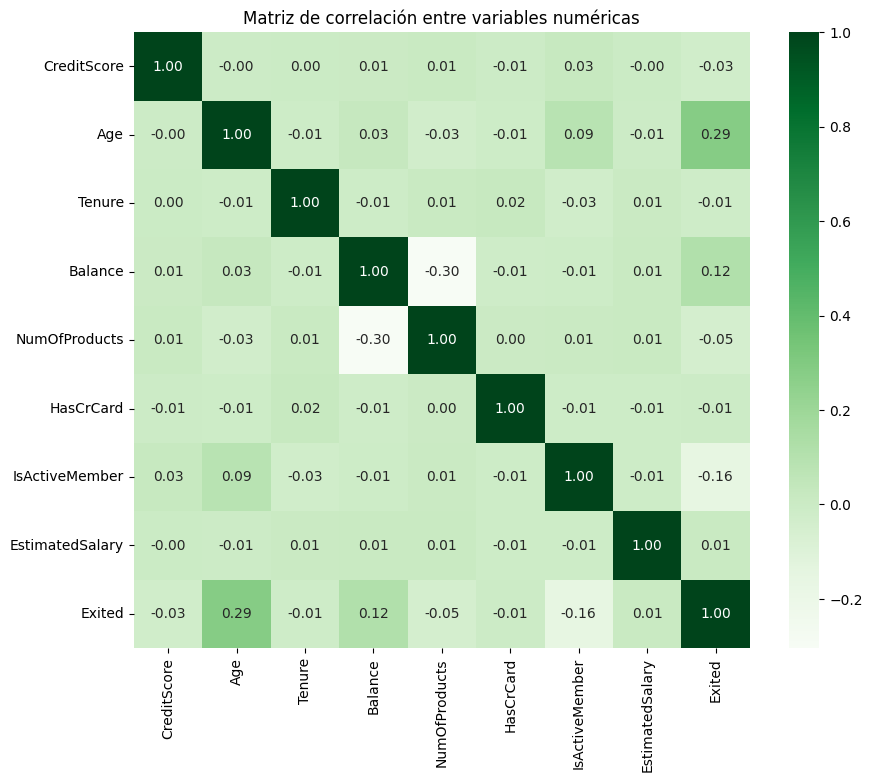

In [40]:
num_cols = df.select_dtypes(include=[np.number])
corr_matrix = num_cols.corr(method="pearson")
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    square=True
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

**Conclusion de la matriz de correlacion:**
- No hay correlaciones extremadamente altas entre variables explicativas -> No hay multicolinealidad grave
- El churn (Exited) no depende de una sola variable, sino de una combinación de factores
- Variables más relacionadas con el Exited son: 
    - Age ↔ Exited → 0.29 (A mayor edad, mayor probabilidad de abandono)
    - IsActiveMember ↔ Exited → −0.16 (Clientes activos abandonan menos)
    - Balance ↔ Exited → 0.12 (Clientes con mayor saldo tienden levemente a abandonar más)


## 4. Training

=== Confusion Matrix ===
[[1156  437]
 [ 134  273]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1593
           1       0.38      0.67      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.71      0.74      2000

PR-AUC: 0.3882680412943825
ROC-AUC: 0.7511394291055309


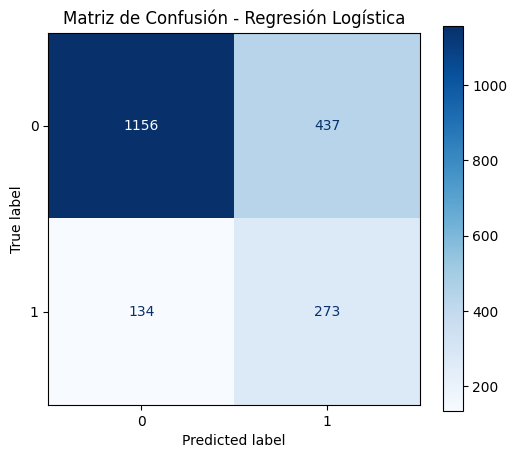

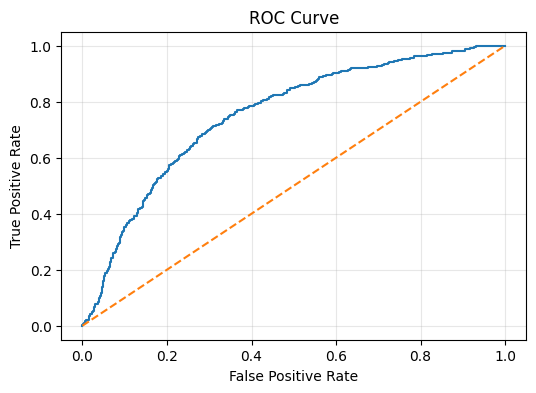

In [48]:

#se entrena por optimización iterativa de un maximo de 2000
# "balanced" ajusta pesos automáticamente
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")

# se ejecutan en orden: preprocess (transformaciones numericas y categoricas) y model (entrenar/predecir con LogReg)
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

#Aprende los coeficientes β de la logística.
clf.fit(X_train, y_train)

#Predict devuelve la clase final según un umbral (por defecto 0.5)
y_pred = clf.predict(X_test)

#devuelve la matriz con las 2 probabilidades -> 
# devuelve qué tan riesgoso es cada cliente de los de test
y_proba = clf.predict_proba(X_test)[:, 1]

print("=== Confusion Matrix ===")
cm  = confusion_matrix(y_test, y_pred)
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de Confusión - Regresión Logística")
plt.show()

# Curva ROC
fpr, tpr, thr = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True, alpha=0.3)
plt.show()

**MATRIZ DE CONFUSION:**

[[1143  450]

 [ 140  267]]

- 1143: predijo 0 y era 0 (bien)
- 450: predijo 1 y era 0 (falsa alarma)
- 140: predijo 0 y era 1 (se escapo un exited)
- 267: predijo 1 y era 1 (acierto de exited)

**Precision**: 
    De todos los que predijo “exited”, cuántos eran exited de verdad -> 37%
    De todos los que predijo “no exited”, cuántos eran no exited de verdad -> 89%

**Recall**: 
    De todos los 'exited' reales, cuántos detecté -> 66%
    De todos los 'no exited' reales, cuántos detecto -> 72%

**F1-Score**: dice sí, detectás todo, pero a costa de muchas falsas alarmas
    no exited -> 0.79
    exited -> 0.48

**ROC-AUC**: que tan bien separa el modelo exited del no exited. Evalúa la capacidad del modelo para discriminar entre clientes que abandonan y los que permanecen activos. Un valor cercano a 1 indica una excelente capacidad de separación, mientras que un valor cercano a 0.5 representa un desempeño equivalente al azar. En este caso, mide qué tan bien el modelo ordena a los clientes por riesgo de churn. En el grafico se encuentra en 0.73 lo que indica que esta en un nivel intermedio de aleatoriedad lo cual podria mejorarse el modelo aun mas.

### coeficientes β

In [43]:
# 1) Extraer el modelo entrenado
log_reg_fitted = clf.named_steps["model"]

# 2) Extraer nombres de variables después del preprocess
preprocess_fitted = clf.named_steps["preprocess"]

num_features = preprocess_fitted.transformers_[0][2]

cat_encoder = preprocess_fitted.transformers_[1][1].named_steps["onehot"]
cat_features = cat_encoder.get_feature_names_out(
    preprocess_fitted.transformers_[1][2]
)

feature_names = np.concatenate([num_features, cat_features])

# 3) Coeficientes
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": log_reg_fitted.coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(10)

,feature,coef
1,Age,0.812765
6,Geography_Germany,0.718264
3,Balance,0.176489
5,EstimatedSalary,0.045589
7,Geography_Spain,0.042362
2,Tenure,-0.042233
4,NumOfProducts,-0.061409
0,CreditScore,-0.085581
8,Gender_Male,-0.519207


### Interpretación de coeficientes y Odds Ratios

Odds Ratio=e^β

In [44]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df.sort_values("odds_ratio", ascending=False).head(10)


,feature,coef,odds_ratio
1,Age,0.812765,2.254132
6,Geography_Germany,0.718264,2.050870
3,Balance,0.176489,1.193021
5,EstimatedSalary,0.045589,1.046644
7,Geography_Spain,0.042362,1.043272
2,Tenure,-0.042233,0.958646
4,NumOfProducts,-0.061409,0.940439
0,CreditScore,-0.085581,0.917979
8,Gender_Male,-0.519207,0.594992


### Intervalos de confianza

In [45]:
from scipy.stats import norm

X_train_t = preprocess_fitted.transform(X_train)
X_train_t = np.asarray(X_train_t)

# Predicciones de probabilidad
p = clf.predict_proba(X_train)[:, 1]

# Matriz de pesos W
W = np.diag(p * (1 - p))

# Hessiana aproximada
H = X_train_t.T @ W @ X_train_t

# Inversa → varianza de coeficientes
cov_matrix = np.linalg.inv(H)

std_errors = np.sqrt(np.diag(cov_matrix))

z = norm.ppf(0.975)  

coef_df["std_error"] = std_errors
coef_df["ci_low"] = coef_df["coef"] - z * coef_df["std_error"]
coef_df["ci_high"] = coef_df["coef"] + z * coef_df["std_error"]

# Pasamos a Odds Ratios
#coef_df["or_ci_low"] = np.exp(coef_df["ci_low"])
#coef_df["or_ci_high"] = np.exp(coef_df["ci_high"])

coef_df.head(10)

,feature,coef,odds_ratio,std_error,ci_low,ci_high
1,Age,0.812765,2.254132,0.024756,0.764244,0.861286
6,Geography_Germany,0.718264,2.050870,0.028649,0.662113,0.774415
3,Balance,0.176489,1.193021,0.024707,0.128065,0.224913
5,EstimatedSalary,0.045589,1.046644,0.028122,-0.009529,0.100708
7,Geography_Spain,0.042362,1.043272,0.025914,-0.008427,0.093152
2,Tenure,-0.042233,0.958646,0.024753,-0.090749,0.006283
4,NumOfProducts,-0.061409,0.940439,0.057610,-0.174322,0.051504
0,CreditScore,-0.085581,0.917979,0.053600,-0.190634,0.019472
8,Gender_Male,-0.519207,0.594992,0.039842,-0.597297,-0.441117


### Las variables que afectan el churn

C:\Users\julia\AppData\Local\Temp\ipykernel_13920\4210810237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


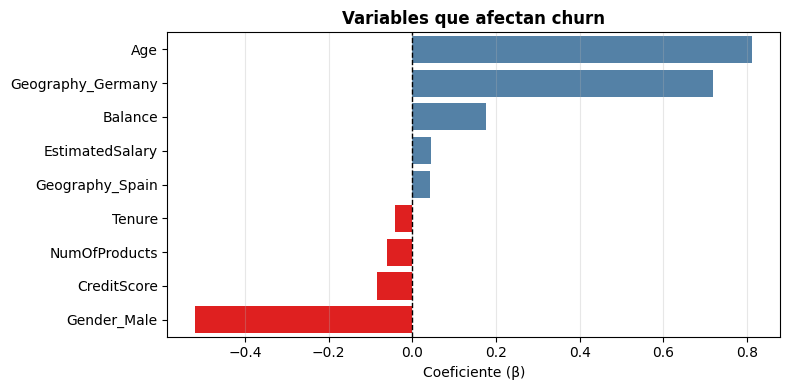

In [46]:
top_pos = coef_df.sort_values("coef", ascending=False).head(10)

# Crear columna de color según el signo
top_pos["color"] = top_pos["coef"].apply(lambda x: "red" if x < 0 else "steelblue")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_pos,
    x="coef",
    y="feature",
    palette=top_pos["color"].tolist()
)

plt.title("Variables que afectan churn", fontweight="bold")
plt.xlabel("Coeficiente (β)")
plt.ylabel("")
plt.grid(True, axis="x", alpha=0.3)

# Línea vertical en 0 para referencia
plt.axvline(0, color="black", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

Algunas conclusiones: 
- Age: si aumenta, **aumenta** un 220% la probabilidad de que surga el churn.
- Geography_Germany: si es Geography_Germany **aumenta** un 215% la probabilidad de que surga el churn.
- Gender_Male: que sea de genero masculino **reduce** un 43% las probabilidad de churn.